# Market Risk Economic Capital Demo

**Economic Capital Simulator** – Market Risk Module  
Ajayvir Khara | Passed FRM Part I and Part II | January 2026

This notebook demonstrates the full Market Risk simulation pipeline:
- Real-world risk factor data download via yfinance
- Covariance calibration (EWMA default, with GARCH comparison)
- 500,000-path Monte Carlo with multivariate Student-t shocks
- 10-day and 1-year VaR/ES at 99.9% confidence
- Euler allocation of Expected Shortfall to individual positions
- Visual breakdown of top contributors

**Expected runtime**: ~60–90 seconds on a standard laptop

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add the project root (parent of notebooks/) to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root added to sys.path:", project_root)
print("Current working directory:", os.getcwd())

# Styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

# Project imports
from econ_capital.market_risk.data_loaders import load_real_risk_factors, load_dummy_positions
from econ_capital.market_risk.engine import MarketRiskEconomicCapital
from econ_capital.market_risk.config import load_market_yaml

Project root added to sys.path: c:\Users\ajayv\OneDrive\Desktop\Files from Cloud\Ajay's Stuff\MSc + Other Files\Economic Capital Simulator
Current working directory: c:\Users\ajayv\OneDrive\Desktop\Files from Cloud\Ajay's Stuff\MSc + Other Files\Economic Capital Simulator\notebooks


## 1. Load Real Historical Risk Factor Returns

In [2]:
%%time

print("Downloading real risk factor returns (2020–2025)...")
risk_factors = load_real_risk_factors(start="2020-01-01", end="2025-01-01")

print(f"Loaded {risk_factors.shape[1]} factors over {risk_factors.shape[0]} trading days")
risk_factors.tail()

Loaded 10 factors over 1257 trading days
CPU times: total: 1.09 s
Wall time: 1.12 s


,SPY,EFA,EEM,TLT,LQD,HYG,GLD,USO,EURUSD=X,GBPUSD=X
Date,,,,,,,,,,
2024-12-24,0.003058,0.003572,-0.002612,-0.002820,0.001992,0.003190,0.003094,0.011115,0.004229,0.008076
2024-12-26,-0.003518,0.004746,-0.000603,0.000740,0.006751,0.002544,0.000935,0.000067,-0.000569,-0.007060
2024-12-27,-0.004472,-0.001443,0.002272,-0.001115,-0.006871,-0.003426,-0.004202,-0.010527,-0.008199,0.009845
2024-12-30,-0.008038,-0.006570,0.000594,0.003915,-0.003190,0.001400,0.004313,-0.011412,0.008037,0.013135
2024-12-31,-0.003336,0.000000,-0.002227,-0.002362,0.006234,-0.000127,-0.002521,-0.003638,-0.005353,0.009757


## 2. Load Sample Portfolio Positions

A stylised £500M+ portfolio across equities, rates, credit, commodities, and FX.

In [3]:
positions = load_dummy_positions()
print(f"Portfolio has {positions.shape[0]} positions")
positions.head(10)

Portfolio has 9 positions


,SPY,EEM,TLT,LQD,HYG,GLD,USO,EURUSD=X,GBPUSD=X
Equity_US,250000000,0,0,0,0,0,0,0,0
Equity_EM,0,150000000,0,0,0,0,0,0,0
Rates,0,0,-1000000000,0,0,0,0,0,0
Credit_IG,0,0,0,-250000000,0,0,0,0,0
Credit_HY,0,0,0,0,-400000000,0,0,0,0
Gold,0,0,0,0,0,100000000,0,0,0
Oil,0,0,0,0,0,0,50000000,0,0
FX_EURUSD,0,0,0,0,0,0,0,250000000,0
FX_GBPUSD,0,0,0,0,0,0,0,0,200000000


## 3. Run Full Monte Carlo Simulation (500,000 paths)

In [4]:
%%time

engine = MarketRiskEconomicCapital(
    risk_factors=risk_factors,
    positions=positions,
    config=load_market_yaml()  # Uses market_config.yaml defaults (EWMA, Student-t df=7, etc.)
)

results = engine.run()
print("Market Risk simulation complete!")

2026-01-08 13:26:13,421 | econ_capital.market_risk.engine | INFO | Initialized MarketRiskEconomicCapital with 10 factors, 500000 paths, seed=42 in 0.005s
2026-01-08 13:26:13,424 | econ_capital.market_risk.engine | INFO | Starting MarketRiskEconomicCapital run with seed=42, n_paths=500000, horizon=10, cov_method=EWMA
2026-01-08 13:26:13,473 | econ_capital.market_risk.engine | INFO | Estimated mu/cov using EWMA in 0.048s
2026-01-08 13:26:15,569 | econ_capital.market_risk.engine | INFO | Simulated 500000 shocks over horizon=10 in 2.144s
2026-01-08 13:26:15,682 | econ_capital.market_risk.engine | INFO | Run completed: VaR10d=68688924.401 ES10d=76266220.665 VaR1y=344815663.872 ES1y=382853389.229 elapsed=2.257s
2026-01-08 13:26:15,683 | econ_capital.market_risk.engine | INFO | Applying predefined stress shocks for stress testing
2026-01-08 13:26:15,685 | econ_capital.market_risk.engine | INFO | Stress Test Result: 1Y Stressed Capital = £608670169


Market Risk simulation complete!
CPU times: total: 2.8 s
Wall time: 2.28 s


## 4. Key Risk Metrics (99.9% Confidence)

In [5]:
metrics = {
    "10-day VaR": results["var_10d_999"],
    "10-day ES": results["es_10d_999"],
    "1-year VaR": results["var_1y_999"],
    "1-year ES": results["es_1y_999"],
}

pd.Series(metrics).apply(lambda x: f"£{x:,.0f}")

10-day VaR     £68,688,924
10-day ES      £76,266,221
1-year VaR    £344,815,664
1-year ES     £382,853,389
dtype: object

## 5. Top Position Contributions to 1-Year Expected Shortfall

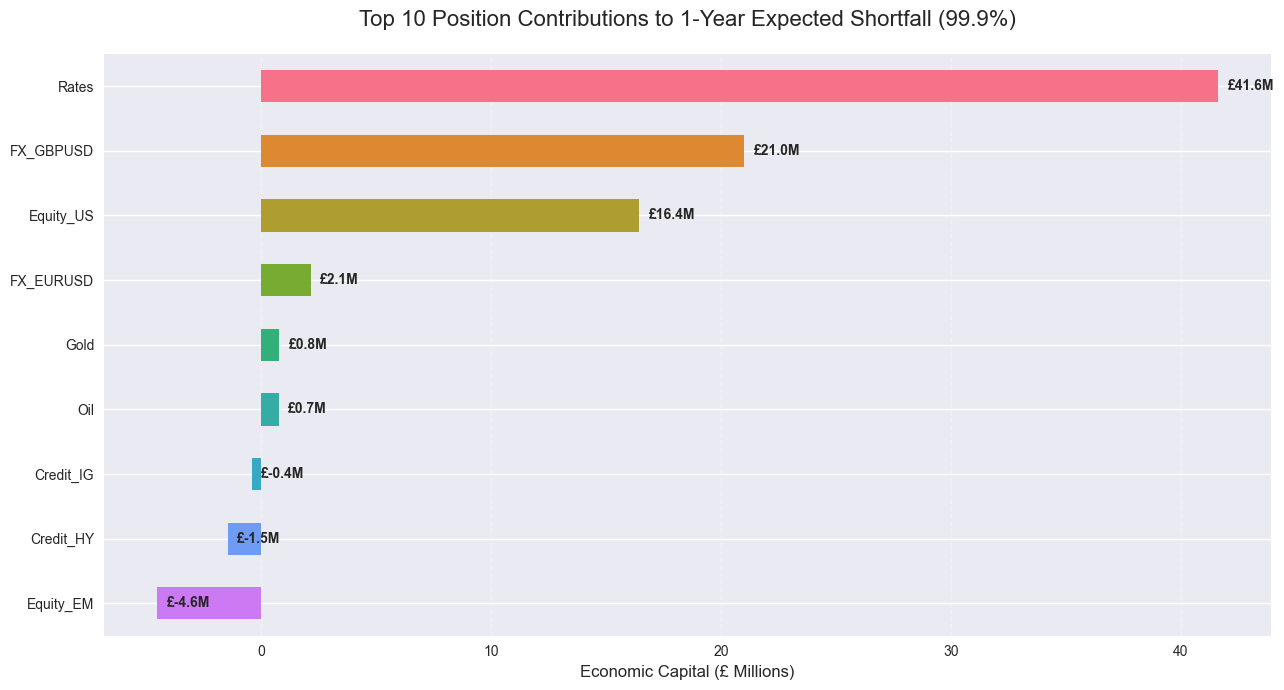

In [6]:
top_10 = results["capital_breakdown"].head(10)

# Convert EC to millions for cleaner display
top_10_millions = top_10 / 1_000_000

plt.figure(figsize=(13, 7))

top_10_millions.plot(kind='barh', color=sns.color_palette("husl", 10))
plt.title("Top 10 Position Contributions to 1-Year Expected Shortfall (99.9%)", fontsize=16, pad=20)
plt.xlabel("Economic Capital (£ Millions)", fontsize=12)
plt.ylabel("")  # Removes default y-label for cleaner look

# Invert so largest contributor is on top
plt.gca().invert_yaxis()

# Grid styling
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Format x-axis: clean £XM labels
import matplotlib.ticker as mticker
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Add value labels on the bars
for i, (idx, value) in enumerate(top_10_millions.items()):
    plt.text(value + max(top_10_millions)*0.01, i, f'£{value:,.1f}M', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Compare Covariance Methods: EWMA vs GARCH

2026-01-08 13:26:21,778 | econ_capital.market_risk.covariance | INFO | Computed GARCH vols for 10 factors in 0.20s
2026-01-08 13:26:21,781 | econ_capital.market_risk.covariance | INFO | Computed GARCH covariance: shape=(10, 10), elapsed=0.412s


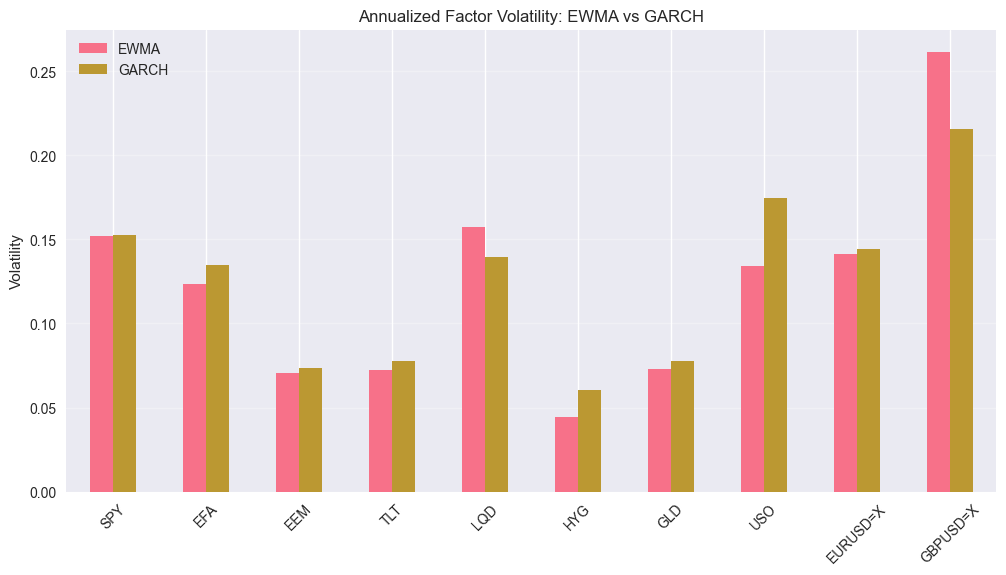

In [7]:
from econ_capital.market_risk.covariance import ewma_cov, garch_cov

ewma_vol = np.sqrt(252 * np.diag(ewma_cov(risk_factors, lamb=0.97)))
garch_vol = np.sqrt(252 * np.diag(garch_cov(risk_factors)))

vol_df = pd.DataFrame({
    'EWMA': ewma_vol,
    'GARCH': garch_vol
}, index=risk_factors.columns)

vol_df.plot(kind='bar', figsize=(12, 6))
plt.title("Annualized Factor Volatility: EWMA vs GARCH")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## 7. Open the Generated Regulatory-Grade Excel Report

In [12]:
import os
import glob

report_pattern = os.path.join(project_root, "econ_capital", "market_risk", "reports", "MarketRisk_EC_Report_*.xlsx")
reports = glob.glob(report_pattern)

if reports:
    latest_report = max(reports, key=os.path.getctime)
    print(f"Opening latest report: {os.path.basename(latest_report)}")
    os.startfile(latest_report)  # Windows
else:
    print("No Market Risk report found.")
    reports_dir = os.path.dirname(report_pattern)
    print(f"Checked directory: {reports_dir}")
    if os.path.exists(reports_dir):
        print("Files in directory:")
        print(os.listdir(reports_dir))
    else:
        print("Reports directory does not exist!")

Opening latest report: MarketRisk_EC_Report_20260106_204324.xlsx


## Next Steps

- Edit `market_config.yaml` to try `cov_method: "GARCH"` or change `df_t`
- Modify positions in `load_dummy_positions()`
- Run the full firm-wide simulation:  
  ```bash
  python econ_capital/run_full_ec.py
  ```

See the other notebooks:
- `demo_credit.ipynb`
- `demo_oprisk.ipynb`